# T.Y. B.Sc. Sem VI (Computer Science) - Data Science Practical Exam Codes
This notebook contains simple Python code solutions for all 22 pages of the practical exam slips. Where Excel/Tableau specific operations (like VLOOKUP, Pivot Tables, Goal Seek) were asked, the Pandas/Python equivalents have been provided.

### Page 1
**Q1: Decision Tree Model using Iris dataset**

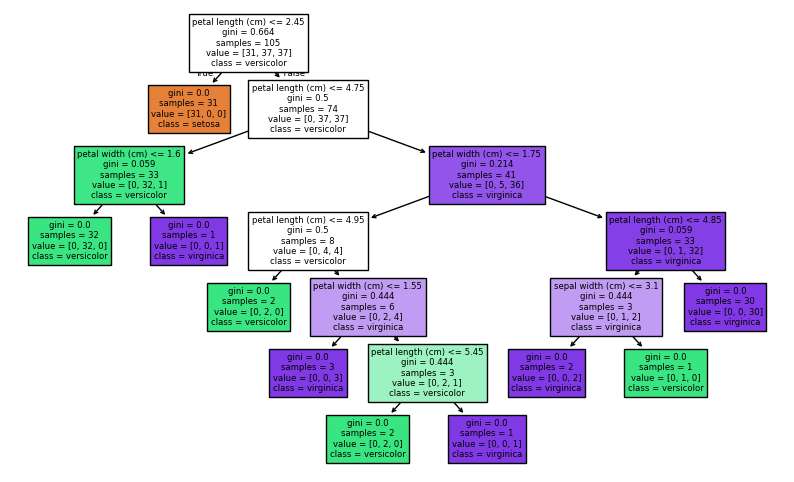

In [4]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.3, random_state=42)

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

plt.figure(figsize=(10,6))
plot_tree(dt, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.show()


### Page 2
**Q1: K-means Algorithm on Iris with Elbow Method**

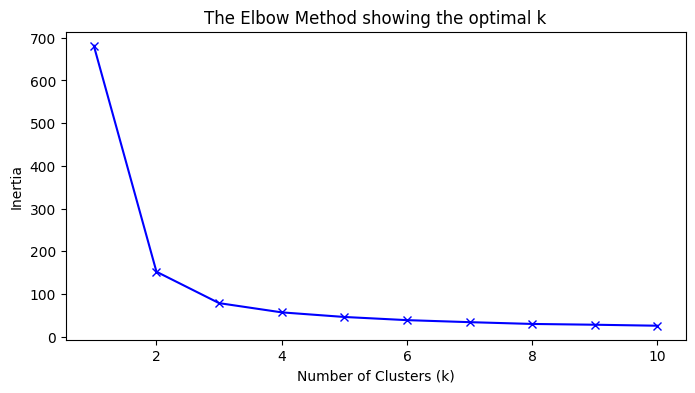

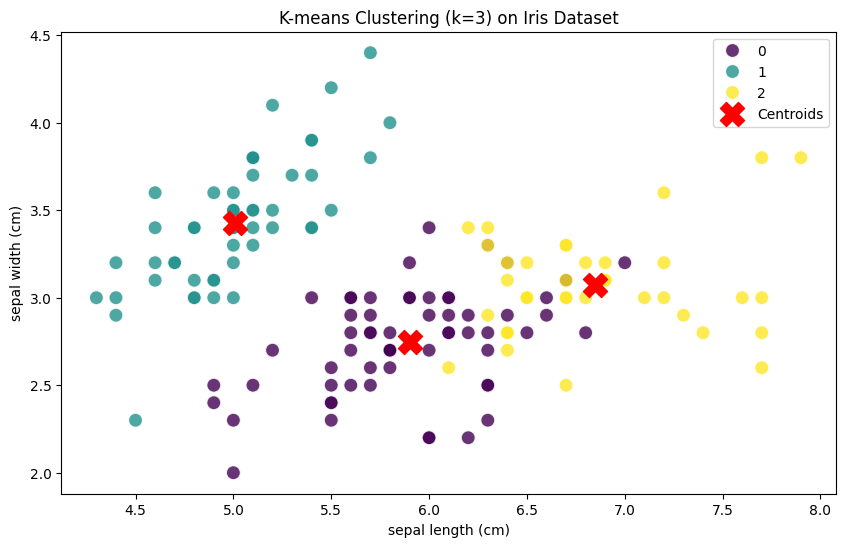

In [29]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
iris = load_iris()
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Elbow Method
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df)
    inertia.append(kmeans.inertia_)

# Plotting the Elbow
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('The Elbow Method showing the optimal k')
plt.show()

# Apply K-means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(df)

# Visualize Results
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='sepal length (cm)', y='sepal width (cm)', 
                hue='cluster', palette='viridis', s=100, alpha=0.8)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            s=300, c='red', marker='X', label='Centroids')
plt.title('K-means Clustering (k=3) on Iris Dataset')
plt.legend()
plt.show()

### Page 3
**Q1: K-means Algorithm on Iris with Silhouette analysis**

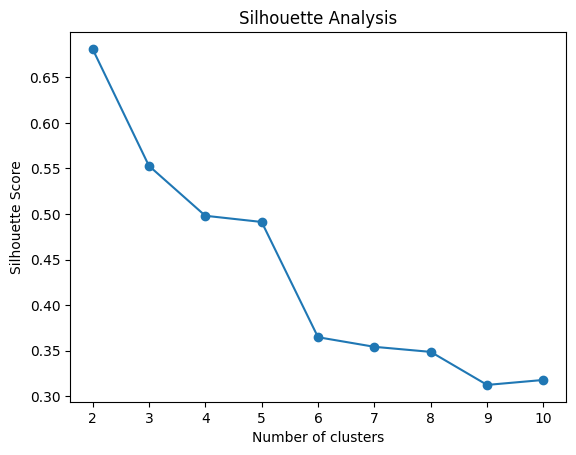

In [6]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

iris = load_iris()
X = iris.data

sil_scores = []
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    preds = kmeans.fit_predict(X)
    sil_scores.append(silhouette_score(X, preds))

plt.plot(range(2, 11), sil_scores, marker='o')
plt.title('Silhouette Analysis')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.show()


### Page 4
**Q1(A): One Sample T-Test**  
**Q1(B): Feature Scaling on Boston Housing**

In [27]:
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# A. One Sample T-Test
scores =[72, 88, 64, 74, 67, 79, 85, 75, 89, 77]
hypothesized_mean = 70

# H0: Mean = 70, H1: Mean != 70
t_stat, p_value = stats.ttest_1samp(scores, hypothesized_mean)
print("T-Test p-value:", p_value)
if p_value < 0.05:
    print("Reject Null Hypothesis. Mean is significantly different from 70.\n")
else:
    print("Fail to reject Null Hypothesis.\n")

# B. Feature Scaling on Boston Housing
# (Note: Boston dataset is deprecated in sklearn 1.2+, fetching from openml)
from sklearn.datasets import fetch_openml
boston = fetch_openml(name='boston', version=1, as_frame=True, parser='auto')
df_boston = boston.frame.dropna()

scaler_std = StandardScaler()
scaler_minmax = MinMaxScaler()

df_standardized = scaler_std.fit_transform(df_boston.select_dtypes(include=[np.number]))
df_normalized = scaler_minmax.fit_transform(df_boston.select_dtypes(include=[np.number]))

print("Standardized Data (first row):\n", df_standardized[0])
print("\nNormalized Data (first row):\n", df_normalized[0])


T-Test p-value: 0.027583862030934297
Reject Null Hypothesis. Mean is significantly different from 70.

Standardized Data (first row):
 [-0.41978194  0.28482986 -1.2879095  -0.14421743  0.41367189 -0.12001342
  0.1402136  -0.66660821 -1.45900038  0.44105193 -1.0755623   0.15968566]

Normalized Data (first row):
 [0.         0.18       0.06781525 0.31481481 0.57750527 0.64160659
 0.26920314 0.20801527 0.28723404 1.         0.08967991 0.42222222]


### Page 5
**Q1(A): Chi-Square Test**  
**Q1(B): Logistic Regression on Iris**

In [8]:
from scipy.stats import chi2_contingency
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# A. Chi-Square Test
aptitude =[85, 65, 50, 68, 87, 74, 65, 96, 68, 94, 73, 84, 85, 87, 91]
jobprof =[70, 90, 80, 89, 88, 86, 78, 67, 86, 90, 92, 94, 99, 93, 87]

chi2, p_val, dof, exp = chi2_contingency([aptitude, jobprof])
print("Chi-Square p-value:", p_val)

# B. Logistic Regression on Iris
iris = load_iris()
X, y = iris.data, iris.target
# Filter to binary classification (class 0 and 1 only)
binary_idx = y != 2
X_bin, y_bin = X[binary_idx], y[binary_idx]

X_tr, X_te, y_tr, y_te = train_test_split(X_bin, y_bin, test_size=0.3, random_state=42)
log_reg = LogisticRegression()
log_reg.fit(X_tr, y_tr)
preds = log_reg.predict(X_te)

print("\nLogistic Regression Accuracy:", accuracy_score(y_te, preds))
print(classification_report(y_te, preds))


Chi-Square p-value: 0.056341110938564386

Logistic Regression Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        17
           1       1.00      1.00      1.00        13

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



### Page 6
**Q1(A): Data Pre-processing**  
**Q1(B): Multiple Linear Regression**

In [3]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

data = {
    'Country':['France', 'Spain', 'Germany', 'Spain', 'Germany', 'France', 'Spain', 'France', 'Germany', 'France'],
    'Age':[44, 27, 30, 38, 40, 35, np.nan, 48, 50, 37],
    'Salary':[72000, 48000, 54000, 61000, np.nan, 58000, 52000, 79000, 83000, 67000],
    'Purchased':['No', 'Yes', 'No', 'No', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes']
}

df_initial = pd.DataFrame(data)
df_initial.to_csv('data.csv', index=False)

df_pre = pd.read_csv('data.csv')

df_pre['Age'].fillna(df_pre['Age'].mean(), inplace=True)
df_pre['Salary'].fillna(df_pre['Salary'].mean(), inplace=True)
print("Preprocessed DataFrame:\n", df_pre.head())

housing_data = {'Bedrooms':[3,3,2,4,3,4,3,3,3,3,3], 'Bathrooms':[1,2.25,1,3,2,4.5,2.25,1.5,1,2.5,2.5],
                'Sqft_living':[1180,2570,770,1960,1680,5420,1715,1060,1780,1890,3560],
                'Price':[221900,538000,180000,604000,510000,267800,257500,291850,229500,323000,662500]}
df_house = pd.DataFrame(housing_data)

X = df_house.drop('Price', axis=1)
y = df_house['Price']
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_tr, y_tr)
preds = lr.predict(X_te)
print(f"R-squared: {r2_score(y_te, preds):.2f}")
print(f"MAE: {mean_absolute_error(y_te, preds):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_te, preds)):.2f}")


Preprocessed DataFrame:
    Country   Age        Salary Purchased
0   France  44.0  72000.000000        No
1    Spain  27.0  48000.000000       Yes
2  Germany  30.0  54000.000000        No
3    Spain  38.0  61000.000000        No
4  Germany  40.0  63777.777778       Yes
R-squared: -145.89
MAE: 340476.46
RMSE: 500932.86


C:\Users\Shreeraj_N_Desai\AppData\Local\Temp\ipykernel_28448\1292512762.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_pre['Age'].fillna(df_pre['Age'].mean(), inplace=True)
C:\Users\Shreeraj_N_Desai\AppData\Local\Temp\ipykernel_28448\1292512762.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values al

### Page 7
**Q1(A): Feature Scaling**  
**Q1(B): Multiple Linear Regression on Pima Indian Diabetes**

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Original Data
cars_data = {'Mileage':[63512, 95135, 75006, 69847, 87278, 138789, 89073, 109231, 87675, 34853, 58173],
             'Sell Price':[4000, 2500, 45000, 3826, 2224, 2723, 3950, 4959, 3791, 4349, 4252]}
df_cars = pd.DataFrame(cars_data)
print("--- Original Data ---\n", df_cars.head(3), "\n")

std_scaler = StandardScaler()
df_standardized = pd.DataFrame(std_scaler.fit_transform(df_cars), columns=df_cars.columns)
print("--- Standardized Data ---\n", df_standardized.head(3), "\n")

norm_scaler = MinMaxScaler()
df_normalized = pd.DataFrame(norm_scaler.fit_transform(df_cars), columns=df_cars.columns)
print("--- Normalized Data ---\n", df_normalized.head(3))

# B. Multiple Linear Regression on Diabetes
# Using a public URL for Pima Indian Diabetes dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
cols =['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']
diabetes = pd.read_csv(url, names=cols)

X = diabetes.drop('class', axis=1)
y = diabetes['class']
model = LinearRegression()
model.fit(X, y)
print("\nDiabetes Model Coefficients:", model.coef_)


--- Original Data ---
    Mileage  Sell Price
0    63512        4000
1    95135        2500
2    75006       45000 

--- Standardized Data ---
     Mileage  Sell Price
0 -0.727329   -0.286753
1  0.477794   -0.412676
2 -0.289303    3.155136 

--- Normalized Data ---
     Mileage  Sell Price
0  0.275737    0.041519
1  0.579992    0.006452
2  0.386324    1.000000

Diabetes Model Coefficients: [ 0.02059187  0.00592027 -0.00233188  0.00015452 -0.00018053  0.01324403
  0.14723744  0.00262139]


### Page 8
**Q1(A): Paired T-Test**  
**Q1(B): Visualization (Python equivalent for Tableau/PowerBI)**

Paired T-test p-value: 0.27922443475463854
No significant difference found.



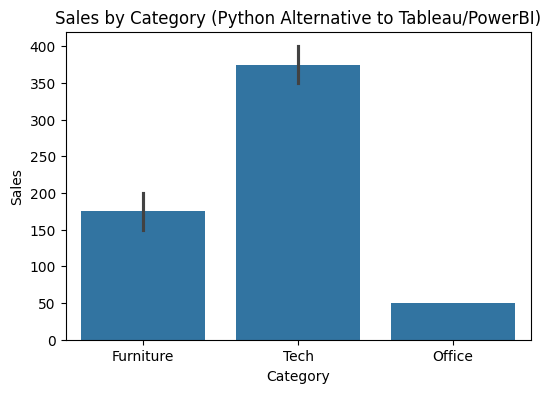

In [11]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# A. Paired T-Test
test1 =[85, 68, 67, 84, 98, 60, 94, 80, 94, 98, 95, 80, 85, 87, 75]
test2 =[70, 90, 80, 89, 88, 86, 78, 87, 90, 86, 92, 94, 99, 93, 86]
t_stat, p_val = stats.ttest_rel(test1, test2)
print("Paired T-test p-value:", p_val)
if p_val < 0.05:
    print("Significant difference. Remedial class improved performance.\n")
else:
    print("No significant difference found.\n")

# B. Visualization (Example for Global Superstore concept)
# Generating dummy superstore-like data to represent the workflow
import pandas as pd
dummy_data = pd.DataFrame({'Category':['Furniture','Tech','Office','Furniture','Tech'],
                           'Sales':[150, 400, 50, 200, 350]})
plt.figure(figsize=(6,4))
sns.barplot(data=dummy_data, x='Category', y='Sales')
plt.title('Sales by Category (Python Alternative to Tableau/PowerBI)')
plt.show()


### Page 9
**Q1(A): Pivot Table Analysis (Pandas equivalent)**  
**Q1(B): Logistic Regression on Iris**

In [12]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# A. Pivot Table in Python
car_data = {
    'Make': ['Honda','Honda','Toyota','Nissan','Toyota','Honda','Ford','Chevrolet','Chevrolet','Dodge','Dodge'],
    'Model':['Accord','Accord','Camry','Altima','Corolla','Civic','F-150','Silverado','Impala','Charger','Charger'],
    'Color':['Red','Blue','Black','Green','Black','White','Black','Green','Silver','Silver','Silver'],
    'Sell Price':[4000,2500,45000,3826,2224,2723,3950,4959,3791,4349,4252],
    'Buy Price':[3000,2000,44000,3000,2100,1900,3000,4500,3500,3500,4000]
}
df = pd.DataFrame(car_data)
df['Profit'] = df['Sell Price'] - df['Buy Price']

print("1. Count by Make, Model, Color:\n", pd.pivot_table(df, index=['Make','Model','Color'], values='Profit', aggfunc='count'))
print("\n2. Profit Margin by Make:\n", pd.pivot_table(df, index='Make', values='Profit', aggfunc='sum'))
print("\n3. Average Cost (Buy Price):\n", df['Buy Price'].mean())
print("\n4. Color Percentage:\n", df['Color'].value_counts(normalize=True)*100)

# B. Logistic Regression (Binary)
iris = load_iris()
X, y = iris.data, iris.target
idx = y != 2
X, y = X[idx], y[idx]
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42)
logr = LogisticRegression().fit(X_tr, y_tr)
print("\nLogistic Regression Accuracy:", accuracy_score(y_te, logr.predict(X_te)))


1. Count by Make, Model, Color:
                             Profit
Make      Model     Color         
Chevrolet Impala    Silver       1
          Silverado Green        1
Dodge     Charger   Silver       2
Ford      F-150     Black        1
Honda     Accord    Blue         1
                    Red          1
          Civic     White        1
Nissan    Altima    Green        1
Toyota    Camry     Black        1
          Corolla   Black        1

2. Profit Margin by Make:
            Profit
Make             
Chevrolet     750
Dodge        1101
Ford          950
Honda        2323
Nissan        826
Toyota       1124

3. Average Cost (Buy Price):
 6772.727272727273

4. Color Percentage:
 Color
Silver    27.272727
Black     27.272727
Green     18.181818
Red        9.090909
Blue       9.090909
White      9.090909
Name: proportion, dtype: float64

Logistic Regression Accuracy: 1.0


### Page 10
**Q1(A): Feature Scaling**  
**Q1(B): PCA on Iris Dataset**

--- Original Data (First 2 rows) ---
   Age  Salary
0   44   72000
1   27   48000 

--- Standardized Array (First 2 rows) ---
[[ 0.82572282  0.48091166]
 [-1.51382518 -1.4111998 ]] 

--- Normalized Array (First 2 rows) ---
[[0.73913043 0.64864865]
 [0.         0.        ]]


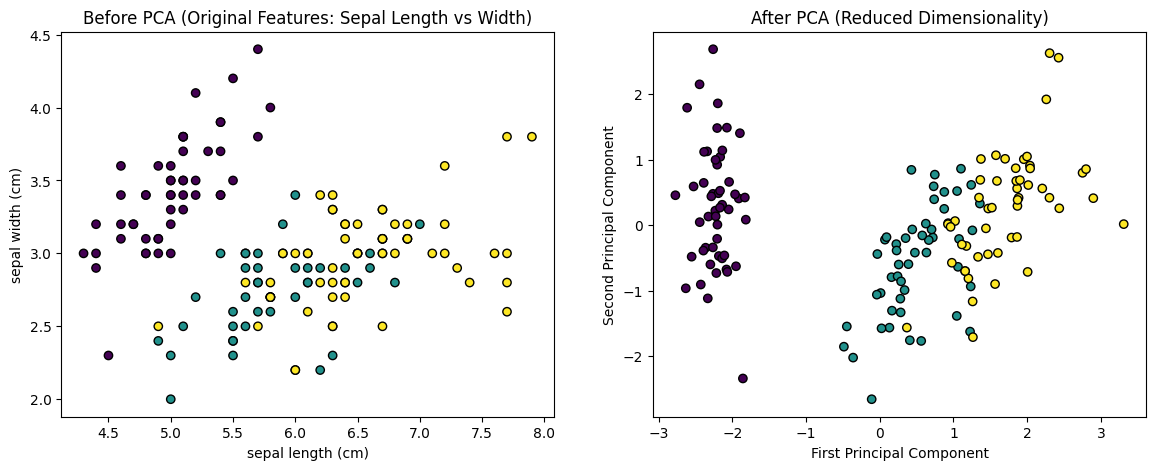

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris

# A. Feature Scaling
data = {'Age':[44,27,30,38,40,35,31,48,50,37], 
        'Salary':[72000,48000,54000,61000,85000,58000,52000,79000,83000,67000]}
df = pd.DataFrame(data)

print("--- Original Data (First 2 rows) ---")
print(df.head(2), "\n")

std_scaler = StandardScaler()
standardized_data = std_scaler.fit_transform(df)
print("--- Standardized Array (First 2 rows) ---")
print(standardized_data[:2], "\n")

norm_scaler = MinMaxScaler()
normalized_data = norm_scaler.fit_transform(df)
print("--- Normalized Array (First 2 rows) ---")
print(normalized_data[:2])

# B. PCA on Iris
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Load Data
iris = load_iris()
X = iris.data
y = iris.target

# Create a figure with 2 side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- PLOT 1: BEFORE PCA (Using first two original features) ---
# X[:, 0] is Sepal Length, X[:, 1] is Sepal Width
scatter1 = axes[0].scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='k')
axes[0].set_xlabel(iris.feature_names[0])
axes[0].set_ylabel(iris.feature_names[1])
axes[0].set_title('Before PCA (Original Features: Sepal Length vs Width)')

# --- PLOT 2: AFTER PCA (Reduced to 2 Principal Components) ---
# Scale and apply PCA
X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', edgecolor='k')
axes[1].set_xlabel('First Principal Component')
axes[1].set_ylabel('Second Principal Component')
axes[1].set_title('After PCA (Reduced Dimensionality)')

plt.show()

### Page 11
**Q1(A): Feature Dummification**  
**Q1(B): Logistic Regression on Iris**

In [14]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# A. Feature Dummification
data = {'Country':['France','Spain','Germany','Spain','Germany','France','Spain','France','Germany','France']}
df = pd.DataFrame(data)
df_dummies = pd.get_dummies(df, columns=['Country'])
print("Dummified DataFrame:\n", df_dummies.head(3))

# B. Logistic Regression (Binary)
iris = load_iris()
X, y = iris.data[iris.target != 2], iris.target[iris.target != 2]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LogisticRegression().fit(X_train, y_train)
print("\nLogistic Regression Score:", model.score(X_test, y_test))


Dummified DataFrame:
    Country_France  Country_Germany  Country_Spain
0            True            False          False
1           False            False           True
2           False             True          False

Logistic Regression Score: 1.0


### Page 12
**Q1(A): Data Transformations**  
**Q1(B): PCA on Iris**

In [15]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# A. Transformations
car_data = {'Make':['Honda','Honda','Toyota','Nissan'], 'Sell Price':[4000, 2500, 45000, 3826]}
df = pd.DataFrame(car_data)

print("Sell Price > 4000:\n", df[df['Sell Price'] > 4000])
print("\nSorted Data:\n", df.sort_values(by='Sell Price', ascending=True))
print("\nGrouped Data (Mean Price):\n", df.groupby('Make').mean(numeric_only=True))

# B. PCA on Iris
iris = load_iris()
pca = PCA(n_components=2)
pca_data = pca.fit_transform(StandardScaler().fit_transform(iris.data))
print("\nPCA Variance Ratio:", pca.explained_variance_ratio_)


Sell Price > 4000:
      Make  Sell Price
2  Toyota       45000

Sorted Data:
      Make  Sell Price
1   Honda        2500
3  Nissan        3826
0   Honda        4000
2  Toyota       45000

Grouped Data (Mean Price):
         Sell Price
Make              
Honda       3250.0
Nissan      3826.0
Toyota     45000.0

PCA Variance Ratio: [0.72962445 0.22850762]


### Page 13
**Q1(A): One Way ANOVA Test**  
**Q1(B): PCA on Wine Quality**

ANOVA p-value: 2.7271335003318353e-05
Reject Null: Significant difference exists among classes.



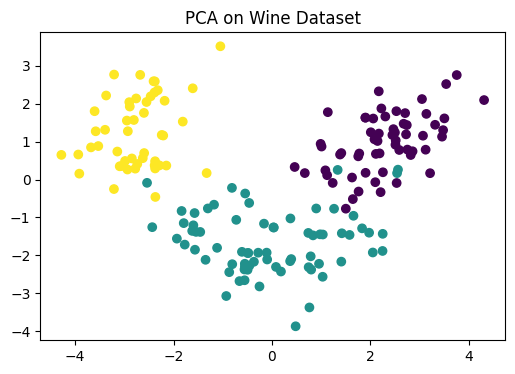

In [16]:
import scipy.stats as stats
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# A. One Way ANOVA
class_A =[85, 90, 88, 82, 87]
class_B =[76, 78, 80, 81, 75]
class_C =[92, 88, 94, 89, 90]

f_stat, p_value = stats.f_oneway(class_A, class_B, class_C)
print("ANOVA p-value:", p_value)
if p_value < 0.05:
    print("Reject Null: Significant difference exists among classes.\n")

# B. PCA on Wine
wine = load_wine()
X_scaled = StandardScaler().fit_transform(wine.data)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6,4))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=wine.target)
plt.title('PCA on Wine Dataset')
plt.show()


### Page 14
**Q1(A): Two Sample T-Test**  
**Q1(B): Multiple Linear Regression on Pima**

In [17]:
import scipy.stats as stats
import pandas as pd
from sklearn.linear_model import LinearRegression

# A. Two Sample T-Test
grp1 =[85,95,100,80,90,97,104,95,88,92,94,99]
grp2 =[83,85,96,92,100,104,94,95,88,90,93,94]
t_stat, p_value = stats.ttest_ind(grp1, grp2)
print("Two-sample T-test p-value:", p_value)

# B. MLR on Pima Diabetes
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
df = pd.read_csv(url, header=None)
X, y = df.iloc[:, :-1], df.iloc[:, -1]
model = LinearRegression().fit(X, y)
print("\nPima Linear Regression R^2:", model.score(X, y))


Two-sample T-test p-value: 0.8734079490313532

Pima Linear Regression R^2: 0.303253095650892


### Page 15
**Q1: Decision Tree on PlayTennis**

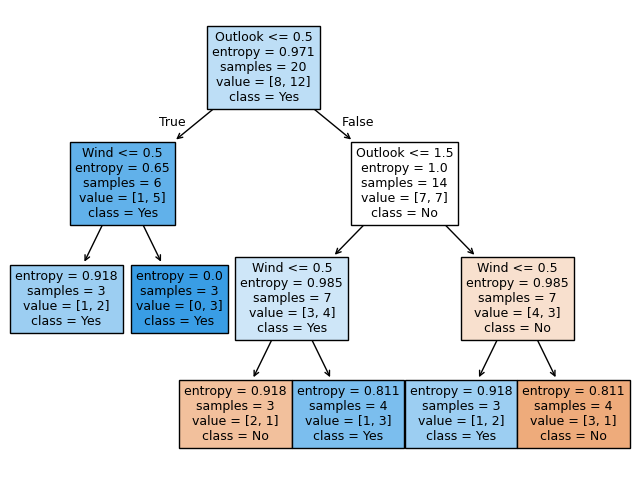

In [18]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

data = {
    'Outlook':['Sunny','Sunny','Overcast','Rain','Rain','Rain','Overcast','Sunny','Sunny','Rain','Sunny','Overcast','Overcast','Rain','Sunny','Overcast','Overcast','Rain','Sunny','Rain'],
    'Wind':['Weak','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Strong','Strong','Strong','Weak','Weak','Weak','Strong'],
    'PlayTennis':['No','No','Yes','Yes','Yes','No','Yes','No','Yes','Yes','Yes','Yes','Yes','No','Yes','No','Yes','No','No','Yes']
}
df = pd.DataFrame(data)
le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])

X = df[['Outlook', 'Wind']]
y = df['PlayTennis']
clf = DecisionTreeClassifier(criterion='entropy')
clf.fit(X, y)

plt.figure(figsize=(8,6))
plot_tree(clf, feature_names=['Outlook','Wind'], class_names=['No','Yes'], filled=True)
plt.show()


### Page 16
**Q1(A): DT on Titanic & Linear Regression (Height/Weight)**  
**Q1(B): Transformation on Car Dataset**

In [19]:
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression

# A1. Decision Tree on Titanic
titanic = sns.load_dataset('titanic').dropna(subset=['age', 'fare', 'survived'])
X_ti = titanic[['age', 'fare']]
y_ti = titanic['survived']
dt = DecisionTreeClassifier(max_depth=3).fit(X_ti, y_ti)
print("Titanic DT accuracy:", dt.score(X_ti, y_ti))

# A2. Linear Regression (Height/Weight)
height = np.array([151,174,138,186,128,136,179,163,152]).reshape(-1, 1)
weight = np.array([63,81,56,91,47,57,76,72,62])
lr = LinearRegression().fit(height, weight)
print("Weight prediction for 170cm height:", lr.predict([[170]]))

# B. Transformation on car dataset
car_data = {'Make': ['Honda','Toyota'], 'Model': ['Accord','Camry'], 'Buy Price':[3000, 44000]}
df_car = pd.DataFrame(car_data)
print("\nCars with Buy Price >= 3000:\n", df_car[df_car['Buy Price'] >= 3000])
print("\nGrouped by Model:\n", df_car.groupby('Model').sum(numeric_only=True))


Titanic DT accuracy: 0.7072829131652661
Weight prediction for 170cm height: [76.24358209]

Cars with Buy Price >= 3000:
      Make   Model  Buy Price
0   Honda  Accord       3000
1  Toyota   Camry      44000

Grouped by Model:
         Buy Price
Model            
Accord       3000
Camry       44000


### Page 17
**Q1(A): Linear Regression on Experience/Salary**  
**Q1(B): VLOOKUP Alternative (Pandas loc)**

In [20]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

# A. Linear Regression
exp = np.array([2, 10, 4, 20, 8, 12, 22]).reshape(-1, 1)
salary = np.array([30000, 95000, 45000, 178000, 84000, 120000, 200000])
model = LinearRegression().fit(exp, salary)
print("Predicted salary for 15 years exp:", model.predict([[15]]))

# B. VLOOKUP with Pandas
data_parts = {
    'Supplier ID':['SP301','SP318','SP305','SP308'],
    'Part Number': ['A002','A018','A005','A008'],
    'Part Name':['altenator','Ball Joint','muffler','rotors'],
    'Part Price':[3800, 2500, 1600, 8549],
    'Status':['In', 'In', 'In', 'Out of stock']
}
df = pd.DataFrame(data_parts)

print("\nPart Name for A002:", df.loc[df['Part Number'] == 'A002', 'Part Name'].values[0])
print("Supplier ID for Ball Joint:", df.loc[df['Part Name'] == 'Ball Joint', 'Supplier ID'].values[0])
print("Part Price for muffler:", df.loc[df['Part Name'] == 'muffler', 'Part Price'].values[0])
print("Status of A008:", df.loc[df['Part Number'] == 'A008', 'Status'].values[0])


Predicted salary for 15 years exp: [139857.5]

Part Name for A002: altenator
Supplier ID for Ball Joint: SP318
Part Price for muffler: 1600
Status of A008: Out of stock


### Page 18
**Q1: Decision Tree on Restaurant Dataset**

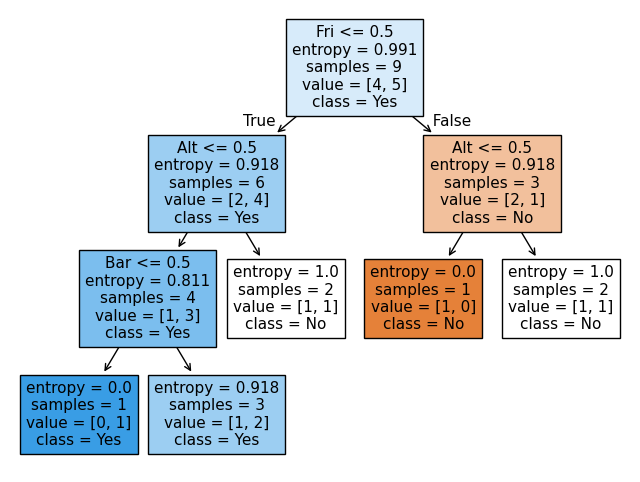

In [21]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

data = {
    'Alt':['Yes','Yes','No','Yes','Yes','No','No','No','No'],
    'Bar':['No','No','Yes','No','No','Yes','Yes','No','Yes'],
    'Fri':['No','No','No','Yes','Yes','No','No','No','Yes'],
    'Wait':['Yes','No','Yes','Yes','No','Yes','No','Yes','No']
}
df = pd.DataFrame(data)
le = LabelEncoder()
df_enc = df.apply(le.fit_transform)

X = df_enc.drop('Wait', axis=1)
y = df_enc['Wait']
dt = DecisionTreeClassifier(criterion='entropy').fit(X, y)

plt.figure(figsize=(8,6))
plot_tree(dt, feature_names=X.columns, class_names=['No','Yes'], filled=True)
plt.show()


### Page 19
**Q1(A): Linear Regression on Iris**  
**Q1(B): Goal Seek Alternative using Python math**

In [22]:
from sklearn.datasets import load_iris
from sklearn.linear_model import LinearRegression
import numpy as np

# A. Linear Regression on Iris (petal.width on petal.length)
iris = load_iris()
X = iris.data[:, 2].reshape(-1, 1) # Petal length
y = iris.data[:, 3] # Petal width
model = LinearRegression().fit(X, y)
print("Coefficient (Slope):", model.coef_[0])

# B. Goal Seek Alternative
# Given scores: 58, 70, 72, 60. Final Exam is unknown. 
# The 'Final Grade' is the average of 5 components.
target_average = 72
current_scores = [58, 70, 72, 60]
n_components = 5

required_final = (target_average * n_components) - sum(current_scores)
print("\nMarks required in Final Exam to achieve 72 average:", required_final)


Coefficient (Slope): 0.41575541635241153

Marks required in Final Exam to achieve 72 average: 100


### Page 20
**Q1(A): Linear Regression on Iris**  
**Q1(B): VLOOKUP on Part Dataset**

In [23]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.linear_model import LinearRegression

# A. Linear Regression
iris = load_iris()
X = iris.data[:, 2].reshape(-1, 1) 
y = iris.data[:, 3] 
lr = LinearRegression().fit(X, y)
print("R-squared Score:", lr.score(X,y))

# B. VLOOKUP using loc
data_parts = {
    'Supplier ID':['SP316','SP314','SP310','SP320'],
    'Part Number':['A016','A014','A010','A020'],
    'Part Name':['Fuel Filter','Oil Pump','brake','Piston'],
    'Part Price':[1280, 4660, 1500, 4500],
    'Status':['In', 'In', 'In', 'Out of stock']
}
df = pd.DataFrame(data_parts)

print("\n1. Part Name for A016:", df.loc[df['Part Number'] == 'A016', 'Part Name'].values[0])
print("2. Supplier ID for Oil Pump:", df.loc[df['Part Name'] == 'Oil Pump', 'Supplier ID'].values[0])
print("3. Part Price for brake:", df.loc[df['Part Name'] == 'brake', 'Part Price'].values[0])
print("4. Status of A020:", df.loc[df['Part Number'] == 'A020', 'Status'].values[0])


R-squared Score: 0.9271098389904927

1. Part Name for A016: Fuel Filter
2. Supplier ID for Oil Pump: SP314
3. Part Price for brake: 1500
4. Status of A020: Out of stock


### Page 21
**Q1(A): Data pre-processing on Student marks dataset**  
**Q1(B): Linear Regression on Iris**

In [24]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.linear_model import LinearRegression

# A. Data Preprocessing
stu_data = {'Rollno':[1,2,3,4,5,6,7,8,9], 'Name':['Sudin','Shaima','Raina','Paul','Rahul','Gopal','Yatin','Jim','Nima'],
            'Age':[44,46,27,38,46,np.nan,59,36,45], 'Marks':[47,86,45,np.nan,45,67,45,34,32]}
df_stu = pd.DataFrame(stu_data)
df_stu['Age'].fillna(df_stu['Age'].median(), inplace=True)
df_stu['Marks'].fillna(df_stu['Marks'].mean(), inplace=True)
print("Preprocessed Data:\n", df_stu.head())

# B. Linear Regression on Iris
iris = load_iris()
X = iris.data[:, 2].reshape(-1, 1)
y = iris.data[:, 3]
model = LinearRegression().fit(X, y)
print("\nIris regression slope:", model.coef_[0])


Preprocessed Data:
    Rollno    Name   Age   Marks
0       1   Sudin  44.0  47.000
1       2  Shaima  46.0  86.000
2       3   Raina  27.0  45.000
3       4    Paul  38.0  50.125
4       5   Rahul  46.0  45.000

Iris regression slope: 0.41575541635241153


C:\Users\Shreeraj_N_Desai\AppData\Local\Temp\ipykernel_40296\4258382357.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_stu['Age'].fillna(df_stu['Age'].median(), inplace=True)
C:\Users\Shreeraj_N_Desai\AppData\Local\Temp\ipykernel_40296\4258382357.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values 

### Page 22
**Q1(A): Logistic Regression on Iris**  
**Q1(B): Pivot Table Analysis on Sales Data**

In [25]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression

# A. Logistic Regression (Binary outcome)
iris = load_iris()
X, y = iris.data[iris.target != 2], iris.target[iris.target != 2]
log_reg = LogisticRegression().fit(X, y)
print("Logistic Regression Score:", log_reg.score(X, y))

# B. Pivot Table / Data Analysis
sales_data = {
    'Color':['Red','Blue','Green','Blue','Green','Red','Blue','Green','Blue','Blue'],
    'Region': ['West','South','West','North','North','South','East','West','East','North'],
    'Units':[1,8,2,7,8,2,5,2,8,7],
    'Sales':[110000,96000,26000,84000,25000,60000,35000,87000,69000,54000]
}
df_sales = pd.DataFrame(sales_data)

print("\n1. Total Sales:", df_sales['Sales'].sum())
print("\n2. Sales Color-wise:\n", df_sales.groupby('Color')['Sales'].sum())
print("\n3. Total Units:", df_sales['Units'].sum())
print("\n4. Region-wise Sales and Units:\n", pd.pivot_table(df_sales, index='Region', values=['Sales','Units'], aggfunc='sum'))


Logistic Regression Score: 1.0

1. Total Sales: 646000

2. Sales Color-wise:
 Color
Blue     338000
Green    138000
Red      170000
Name: Sales, dtype: int64

3. Total Units: 50

4. Region-wise Sales and Units:
          Sales  Units
Region               
East    104000     13
North   163000     22
South   156000     10
West    223000      5
